## Goal

In the previous explorative analyses, we have looked at data that might not be a good representation of what we want to model.

To make the computations faster in the developing phase, we used lower-resolution data (i.e., larger binsize), resulting in fewer steps for the GRW to take. However, as came to mind late in the process, this also could greatly have an influence on the variability of the data, which is a crucial aspect of the GRW model:

The very reasoning for making a Random Walk model is that some of the transitions in the data are not representing true chromatin compartments, but rather noise in the data. When using lower-resolution data, we still assume it is unlikely for a large step to occur between two bins, but that assumption does not hold when the bin-size is 100,000 bp. (Sub)Compartments all the way down to a few hundreds of base pairs have been proposed, so there is no reason to assume a smooth curve between two bins of 100,000 bp.

However, preliminary analyses looks like our sequencing only has enough coverage for 10kb bins, so we will use that as our bin size for the GRW model, ans assume that some of the transitions are in fact noise, and not true compartment transitions.

Initially, we limit ourselves to 1500 bins (1500 steps in the GRW) to serve as a comparable size to the full 100kb track. 

## Load a subset of one of the datasets

Here, we show the full 10kb track, the zoom region, and the zoomed-in region of the 10kb track. The zoomed-in region is then used as `df_zoom` for the following analysis. 

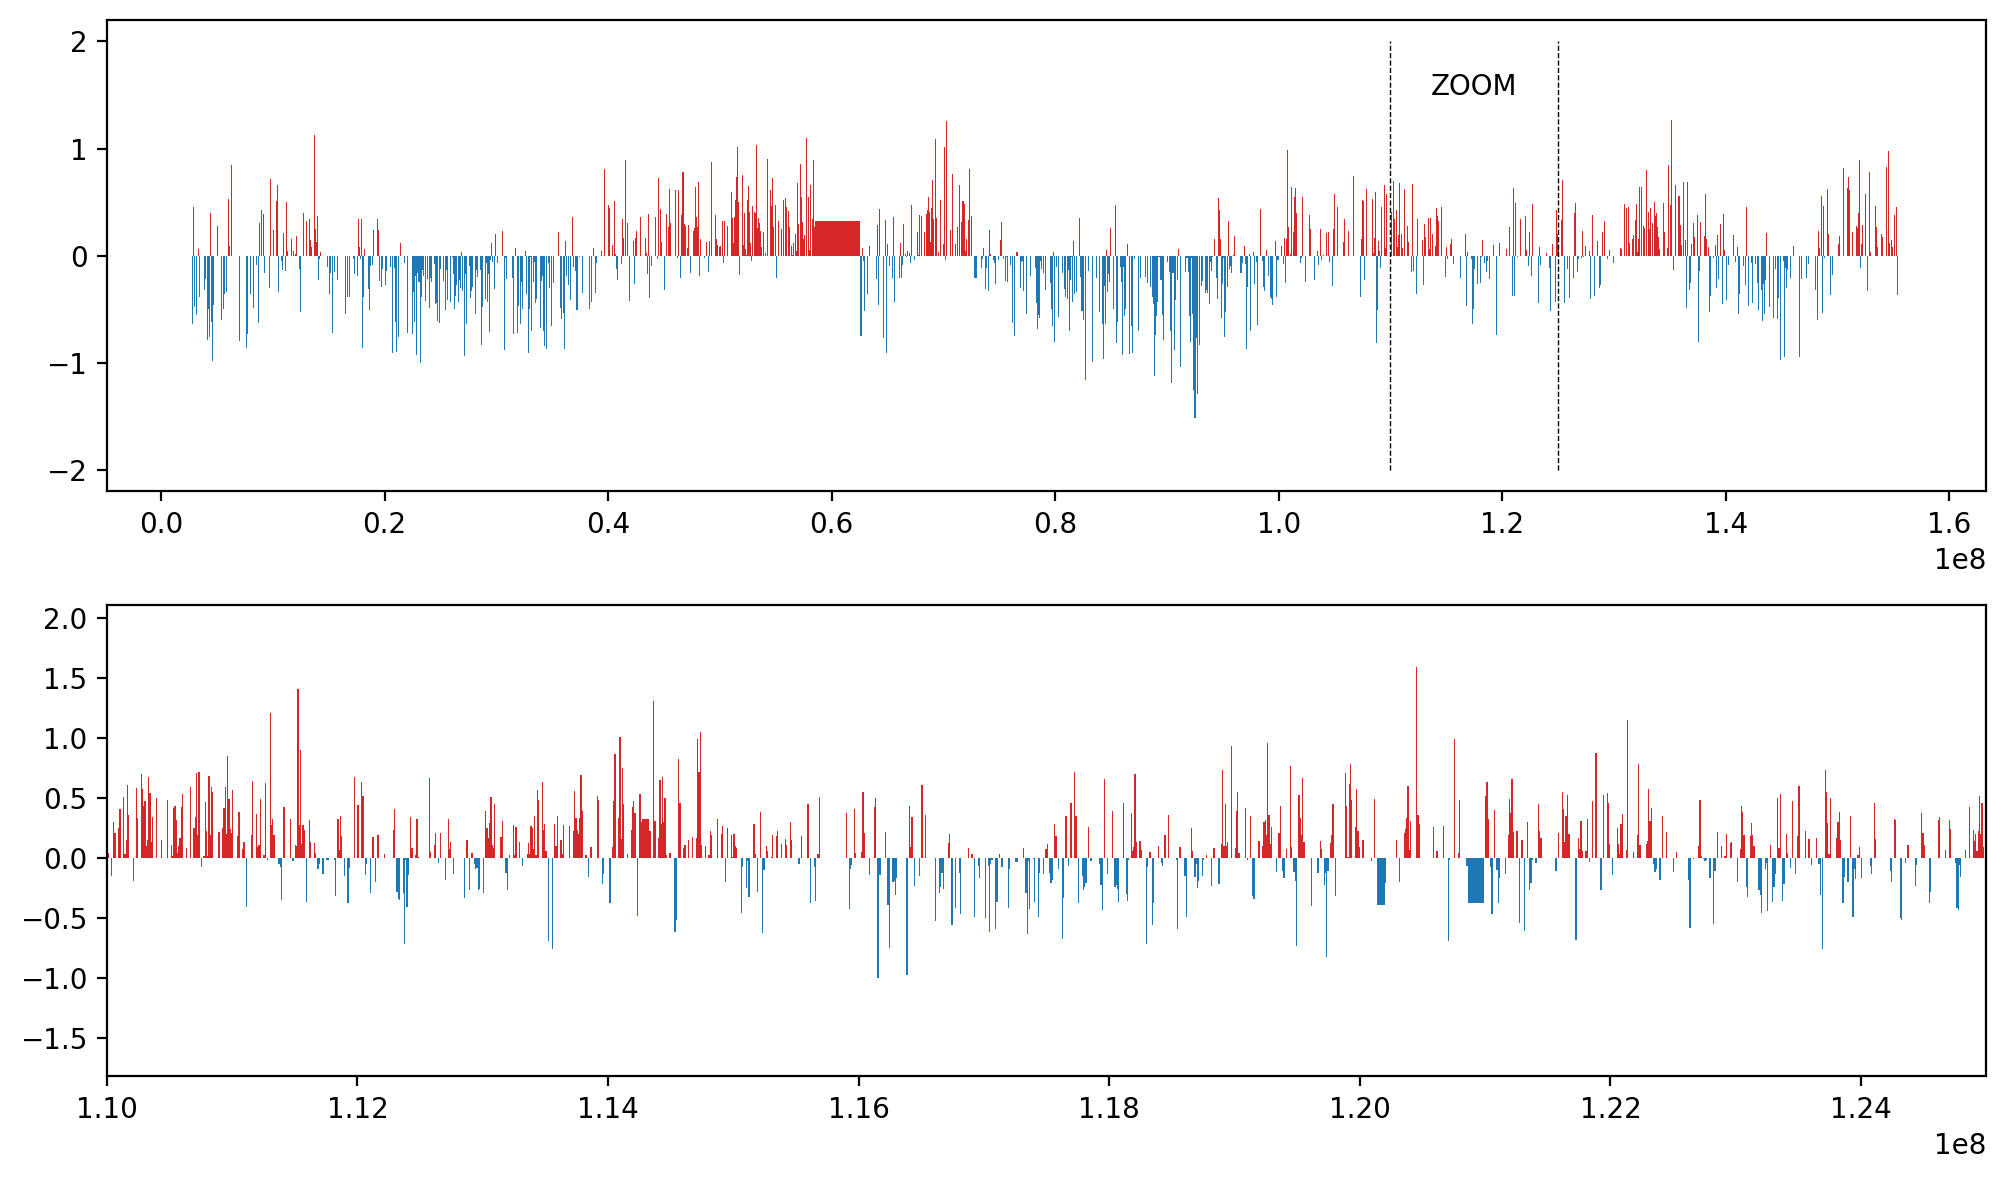

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


# Load the data
resolution = 10000

y = pd.Series(pd.read_csv(f"../data/eigs/sperm_X.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})
df.dropna(inplace=True)

# Plot the data

fig, ax = plt.subplots(2, figsize=(10,6))
ax[0].fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red' , ec='None', step='pre')
ax[0].fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', step='pre') 
#ax[0].set_ylim(-2,2)

# Visualize the zoom and add text
begin_zoom = 1.1e08
zoom = (begin_zoom, begin_zoom + 1500*resolution)
ax[0].vlines(zoom, -2, 2, color='k', lw=0.5, ls='--')
ax[0].text(np.mean(zoom), 1.5, "ZOOM", color='k', ha='center')


ax[1].fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red' , ec='None', step='pre')
ax[1].fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', step='pre') 

ax[1].set_xlim(zoom)
#ax[1].set_ylim(-2,2)

plt.tight_layout()

In [20]:
# Use the zoomed region for further analysis
df_zoom = df.query(f"start >= {zoom[0]} and start <= {zoom[1]}")

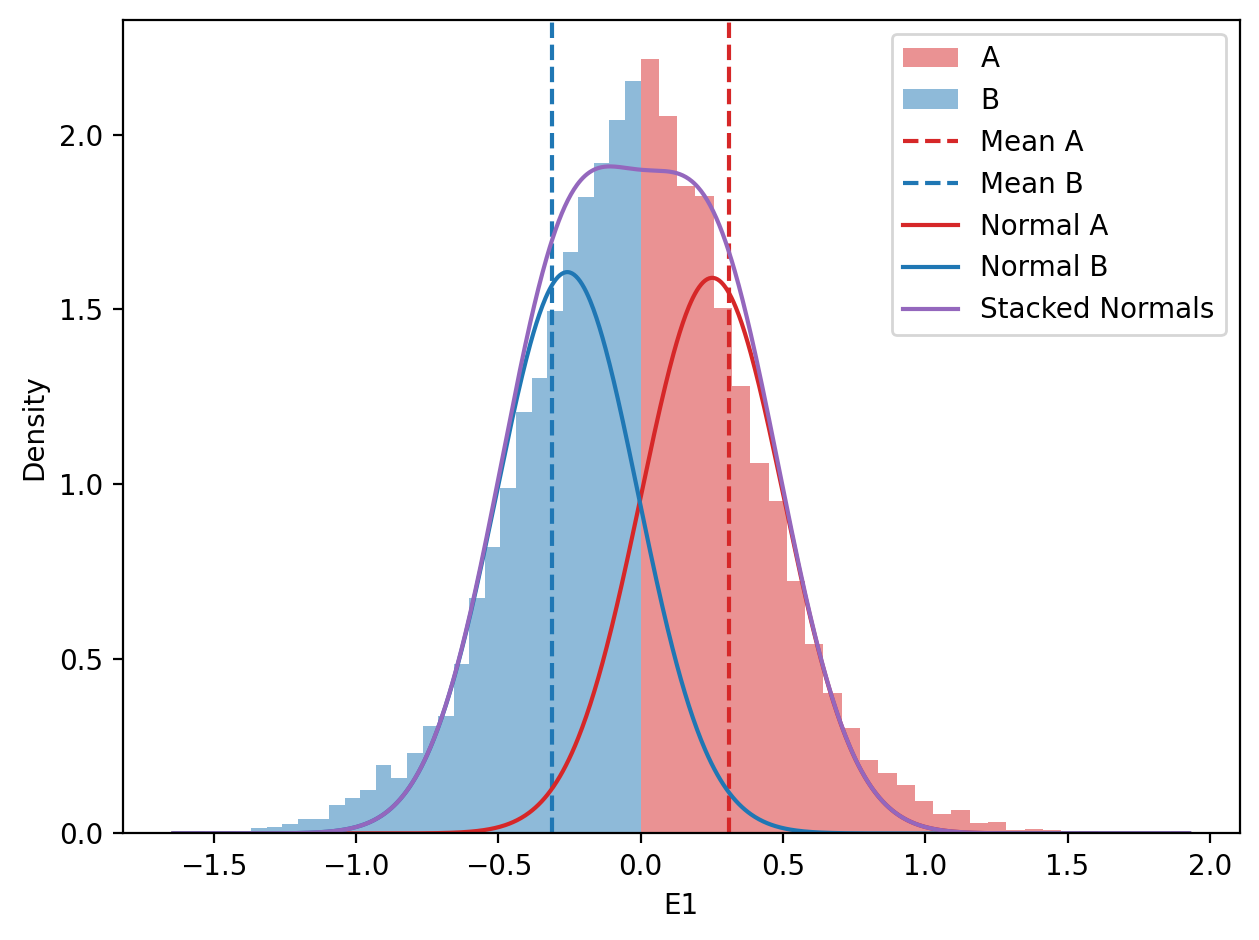

In [21]:
from scipy.stats import norm

# Histogram of distribution of E1 values (A and B)

x = df["start"].values
y = df["e1"].values

f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=30, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=30, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = np.median(y[y>0])
mean_b = np.median(y[y<0])
std_a = y[y>0].std()
std_b = y[y<0].std()

ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

## Model of choice

We use the model architecture decided upon in notebook `05_PyMC_bernoulli_z.ipynb`, called "T_N_HN_10". 

### Model architecture

We assume that we can draw the eigenvectors from two distributions, resulting in a mixture of two distributions. The `components` of this distribution are

- `components = T`: The mixture components for eigenvectors are assumed to be from a StudentT distribution with `nu=10`. Is is a bit more heavy-tailed than a normal distribution with the same mean, meaning we will allow for larger deviations from the mean.

The bins are assumed to be dependent on the state of the previous bin, so a step size, `eps`, is modeled with Random Walk.

- `eps = N`: the step size is drawn from a Normal distribution with `mu=0` and `sigma=1.0`

The walk is modeled as the cumulative sum of steps `pt.cumsum(eps * grw_sigma)`, where

- `grw_sigma = HN`: the standard deviation of the step size is drawn from a HalfNormal distribution with `sigma=0.05`.

Then, it is forced through a sigmoid to ensure values between 0 and 1, and finally, the latent compartment 'state' is inferred by making a Bernoulli draw from the sigmoid output.

### Model factory function

Define the model builder, and import the configuration from file. 

In [3]:
import pymc as pm 
import pytensor.tensor as pt

def build_z_model_from_config(df, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """
    e1 = df.e1.values 
    
    with pm.Model(coords={"pos": df.index.values}) as model:
        # e1 = pm.Data("e1", df.e1.values, dims="pos")

        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, shape=2)
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], shape=2)

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", mu=0.0, sigma=1.0)
        else:
            eps = pm.StudentT("eps", dims="pos", mu=0.0, sigma=1.0, nu=cfg['eps_kwargs']['nu'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps*grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

        # Make a latent variable for the mixture model
        z = pm.Bernoulli("z", p=w, dims="pos")


        y_hat = pm.Mixture("y_hat", w=pt.stack([z,1-z], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model

In [4]:
import json

with open("../results/model_grid.json", "r") as f:
    config_list = json.load(f)

configs = {cfg['name']: cfg for cfg in config_list}

name = "T_N_HN_10"

config = configs[name]
config

{'name': 'T_N_HN_10',
 'comp_dist': 'StudentT',
 'comp_kwargs': {'nu': 10},
 'eps_dist': 'Normal',
 'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
 'grw_sigma_dist': 'HalfNormal',
 'grw_sigma_kwargs': {'sigma': 0.05},
 'mu_mu': [-0.5, 0.5],
 'mu_sigma': 0.3,
 'sigma': 0.3}

In [5]:
# Build the model

model = build_z_model_from_config(df_zoom, config)
model

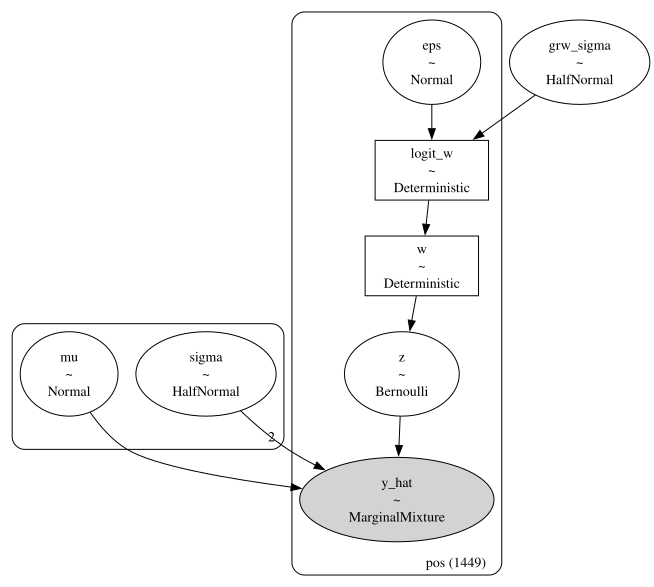

In [6]:
model.to_graphviz()

In [7]:
with model:
    idata = pm.sample(draws=1000, tune=1000, chains=7, cores=7, progressbar=False)
    

Multiprocess sampling (7 chains in 7 jobs)


CompoundStep


>NUTS: [mu, sigma, grw_sigma, eps]


>BinaryGibbsMetropolis: [z]


Sampling 7 chains for 1_000 tune and 1_000 draw iterations (7_000 + 7_000 draws total) took 795 seconds.


There were 215 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [8]:
with model:
    pm.compute_log_likelihood(idata, progressbar=False)
    

In [9]:
with model:
    prior_predictive = pm.sample_prior_predictive(1000)

idata.extend(prior_predictive)

Sampling: [eps, grw_sigma, mu, sigma, y_hat, z]


In [10]:
with model:
    posterior_predictive = pm.sample_posterior_predictive(idata, progressbar=False)

idata.extend(posterior_predictive)

Sampling: [y_hat]


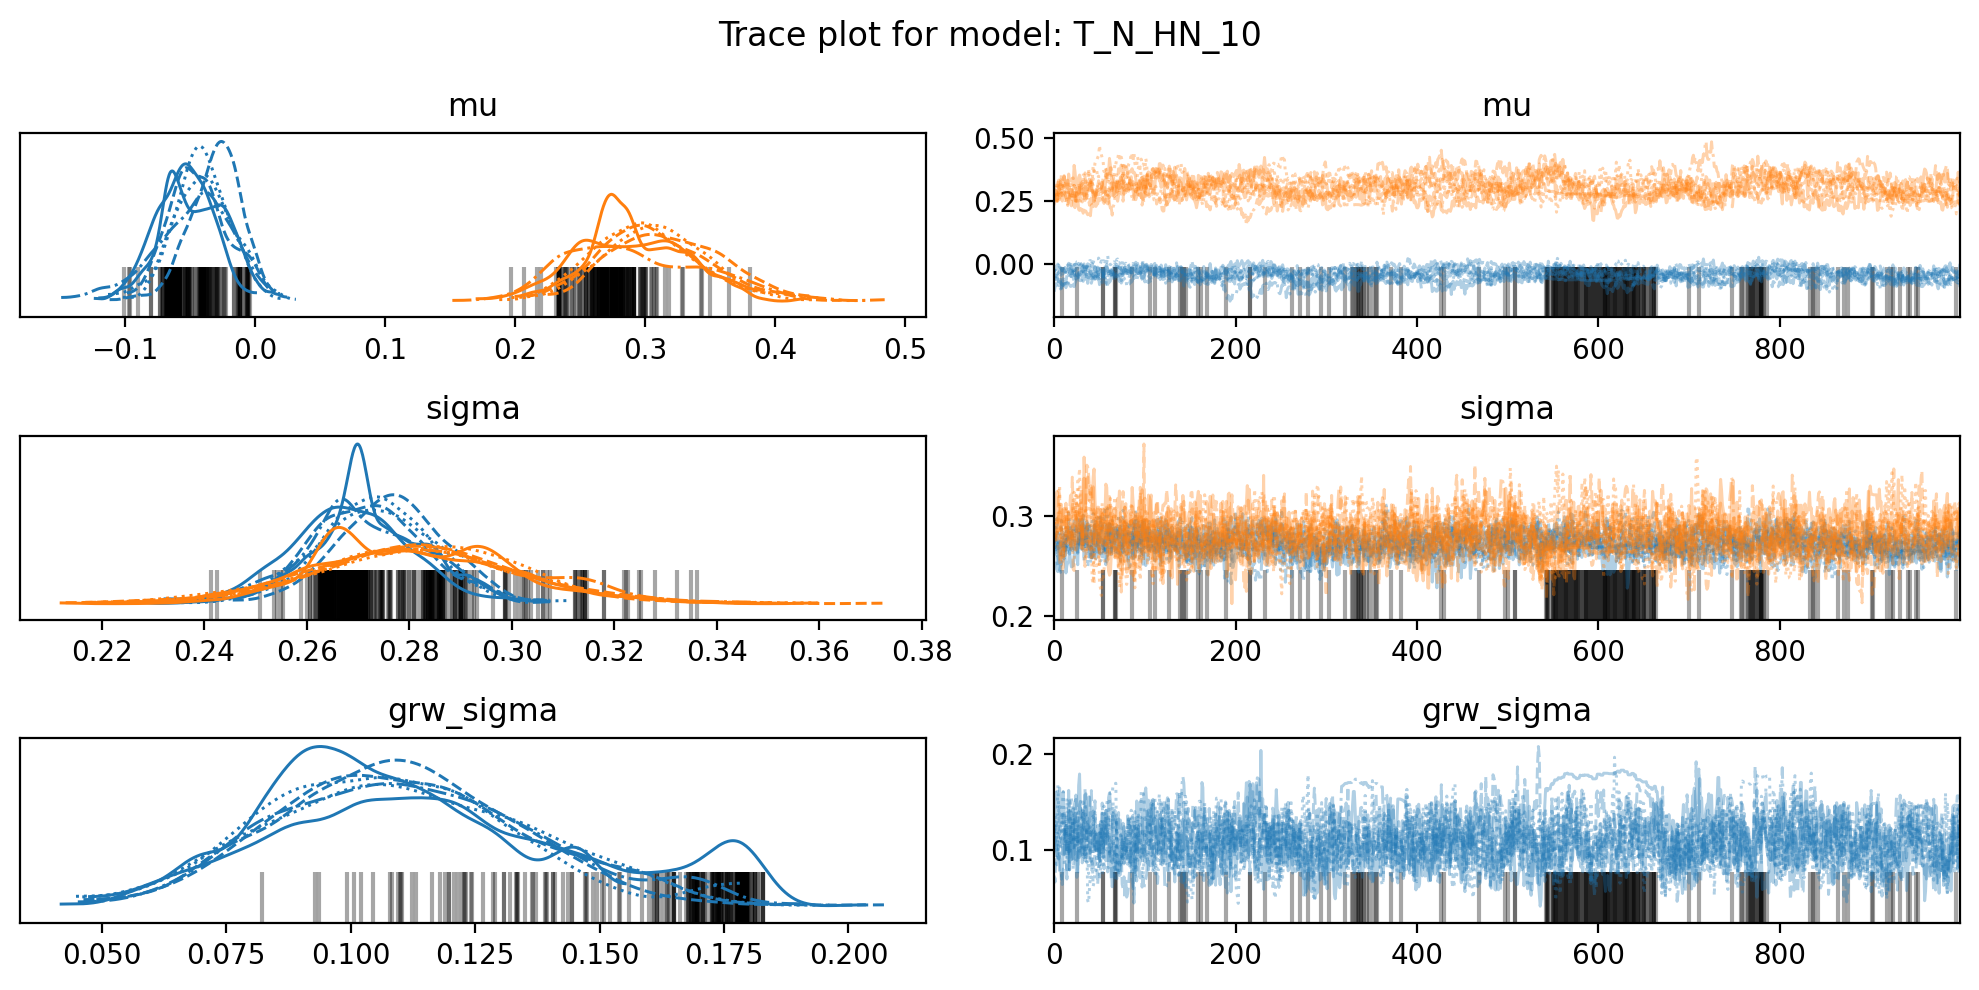

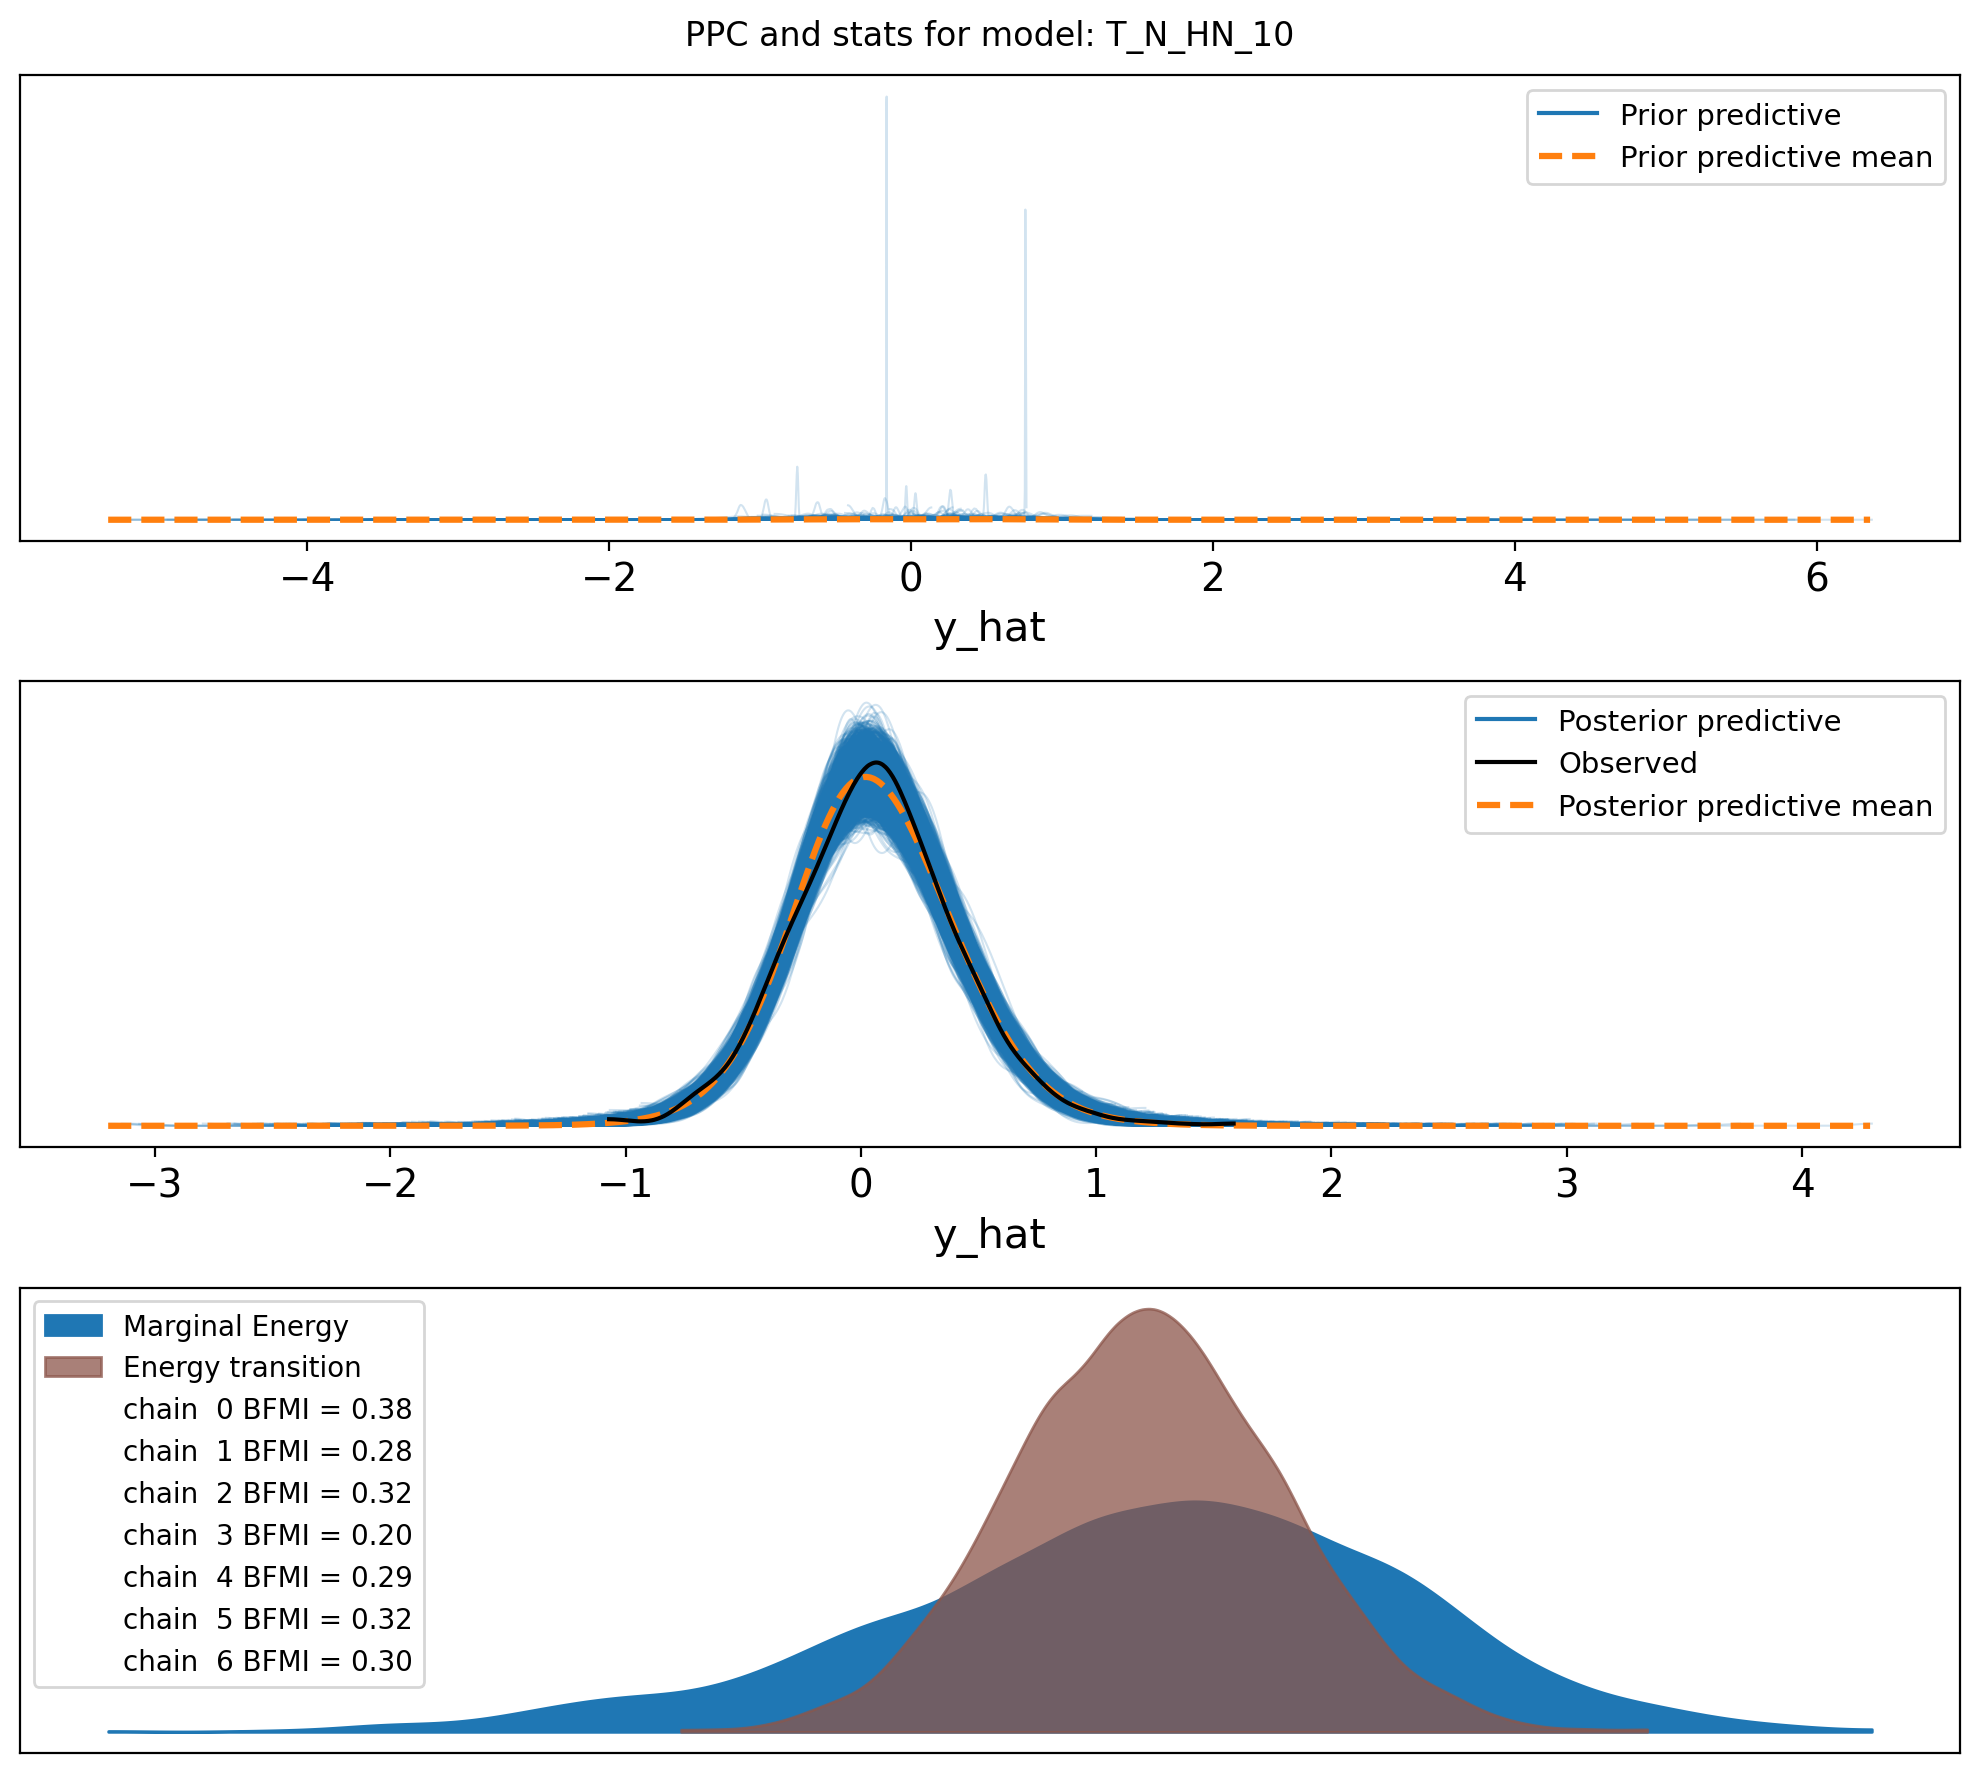

In [11]:
import arviz as az


f, axs = plt.subplots(3, 2, figsize=(10, 5))

az.plot_trace(idata, var_names=["mu", "sigma", "grw_sigma"], compact=True, axes = axs)
plt.suptitle(f"Trace plot for model: {name}")
plt.tight_layout()



f,axs = plt.subplots(3, figsize=(10, 9))
axs = axs.flatten()

az.plot_ppc(idata, var_names=["y_hat"], group="prior", ax=axs[0])
az.plot_ppc(idata, var_names=["y_hat"], ax=axs[1])
az.plot_energy(idata, ax = axs[2])
plt.suptitle(f"PPC and stats for model: {name}")
plt.tight_layout()

So, it looks like the data may not come from two distrinct distributions for E1 values in this sample. I am confused. I guess we go back to the drawing board. 

## Bootstrapping to get a confidence interval

### Bootstrapping helpers

Here, we define a wrapper function to bootstrap the mean for each position. `scipy.stats.bootstrap` is vectorized and is therefore very efficient for resampling each position. However, it will allocate an array of size `n_resamples * n_samples * pos` (1.2 TB for 10,000 resamples), unless we use the `batch`, where it allocates `batch * n_samples * pos` arrays in memory at at time. Here, we define a function to compute the batch value to maximally allocate a 16Gb array in memory at a time.

In [12]:
from scipy.stats import bootstrap
import numpy as np

def compute_batch(arr, max_Gbytes=16):
    """
    Compute max batch size so that each batch of resamples fits in max_bytes.
    """
    max_bytes = max_Gbytes * 1024**3

    # Elements in a single resample
    n_elements = arr.shape[0] * arr.shape[1]
    # Bytes per element
    bytes_per_elem = np.dtype(arr.dtype).itemsize
    # Bytes per resample
    bytes_per_resample = n_elements * bytes_per_elem
    # Max batches
    batch = max(1, int(max_bytes // bytes_per_resample))

    if batch > arr.shape[1]:
        batch = None

    return batch

def bootstrap_mean(stacked_var, **kwargs):
    """Compute the confidence interval for the mean."""

    batch = compute_batch(stacked_var)
    print(f"Computing bootstrap mean with shapes: {stacked_var.shape} in batches of {batch}")

    res = bootstrap(
        (stacked_var,),
        statistic = np.mean,
        vectorized = True,
        axis=1,
        method = "basic",
        batch = batch,
        **kwargs
    )

    return res



The trace (`idata`) is then stacked across chains and draws and converted to 8-bit integers for efficiency.

In [13]:
stacked_z = (
    idata
    .posterior
    .z
    .stack(sample=["chain", "draw"])
    )

stacked_z.data = stacked_z.data.astype(np.uint8)

stacked_z

<xarray.DataArray 'z' (pos: 1449, sample: 7000)> Size: 10MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 0, 1]], shape=(1449, 7000), dtype=uint8)
Coordinates:
  * pos      (pos) int64 12kB 11000 11001 11002 11003 ... 12498 12499 12500
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [14]:
bootstrap_results = bootstrap_mean(
    stacked_z, **{
        "confidence_level": 0.99,
        "n_resamples": 10000,
        }
    )

bootstrap_results

Computing bootstrap mean with shapes: (1449, 7000) in batches of 1693


BootstrapResult(confidence_interval=ConfidenceInterval(low=array([0.13614214, 0.61371429, 0.58128571, ..., 0.70185714, 0.86628571,
       0.28      ], shape=(1449,)), high=array([0.15757214, 0.64314286, 0.61114286, ..., 0.72971429, 0.88614286,
       0.30742857], shape=(1449,))), bootstrap_distribution=array([[0.14628571, 0.13914286, 0.14428571, ..., 0.149     , 0.14685714,
        0.14757143],
       [0.63628571, 0.63042857, 0.62628571, ..., 0.63328571, 0.63014286,
        0.62057143],
       [0.595     , 0.60142857, 0.59642857, ..., 0.60314286, 0.59885714,
        0.58942857],
       ...,
       [0.71071429, 0.70885714, 0.70942857, ..., 0.71342857, 0.71328571,
        0.70785714],
       [0.882     , 0.87614286, 0.875     , ..., 0.87228571, 0.87214286,
        0.87185714],
       [0.293     , 0.27985714, 0.29114286, ..., 0.29514286, 0.28614286,
        0.28614286]], shape=(1449, 10000)), standard_error=array([0.0042392 , 0.00573467, 0.00577615, ..., 0.00533306, 0.00391535,
       0.0

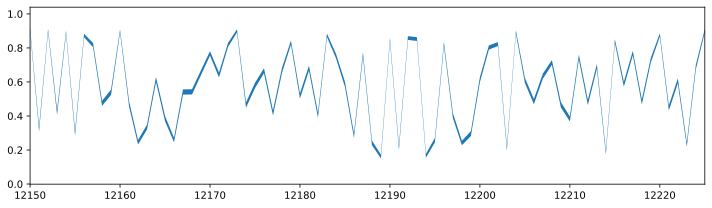

In [15]:
import matplotlib.pyplot as plt
import matplotlib_inline 

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

x = stacked_z.pos.values
lower = bootstrap_results.confidence_interval.low
upper = bootstrap_results.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 3))

ax.fill_between(
    x,
    lower,
    upper,
    label="95% CI",
    # ec = "black",
)
ax.set_xlim(12150,12225)
plt.tight_layout()

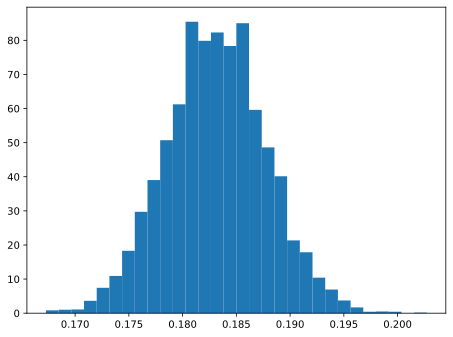

In [16]:
plt.hist(bootstrap_results.bootstrap_distribution[11], density=True, bins=30)
plt.tight_layout()

In [17]:
bootstrap_99 = bootstrap_mean(
    stacked_z, **{
    "n_resamples": 0,
    #"batch": compute_batch(stacked.values),
    "confidence_level": 0.99,
    "bootstrap_result": bootstrap_results
    }
    )

Computing bootstrap mean with shapes: (1449, 7000) in batches of 1693


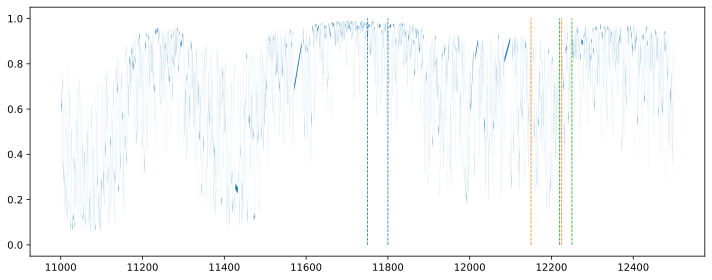

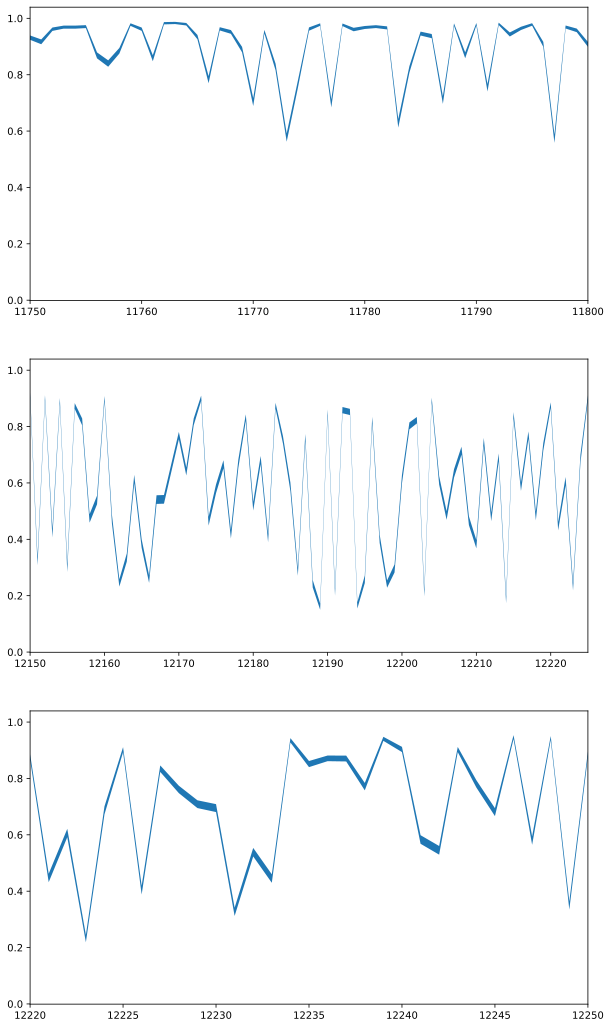

In [18]:
lower_99 = bootstrap_99.confidence_interval.low
upper_99 = bootstrap_99.confidence_interval.high

fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(
    x,
    lower_99,
    upper_99, 
)

zooms = [(11750,11800), (12150,12225), (12220,12250)]
cmap = plt.get_cmap("tab10")

for i, zoom in enumerate(zooms):
    color = cmap(i)
    ax.vlines(zoom, 0, 1, color=color, linestyle="--", linewidth=0.8)

f,axs = plt.subplots(len(zooms), figsize = (10, 6*len(zooms)))
axs = np.asarray(axs).flatten()
for i,zoom in enumerate(zooms):
    zax = axs[i]
    zax.fill_between(
        x,
        lower_99,
        upper_99
    )
    zax.set_xlim(zoom)



# ax[1].fill_between(
#     x,
#     lower_99,
#     upper_99, 
# )
# ax[1].set_xlim(zoom)

fig.tight_layout()
plt.show()

## Estimate certainty predictions in Bernoulli outcomes

As an overview, we can get clues about the validity of the predictions. 

